# 03. Hipoteza 2: Złożoność poznawcza

Sprawdzamy, czy teksty w linkach negatywnych mają niższą złożoność językową niż teksty w linkach pozytywnych.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "database" / "NajnowszaWersjaBazy1205.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH exists:", DATA_PATH.exists())


PROJECT_ROOT: C:\Users\szymon\projekt_reddit
DATA_PATH exists: True


In [2]:
from scipy import stats
from src.reddit_pbl.columns import COGNITIVE_COMPLEXITY_FEATURES
from src.reddit_pbl.features import sentiment_to_binary_negative
from src.reddit_pbl.statistics import compare_groups, point_biserial


In [3]:
df = pd.read_csv(DATA_PATH)

rows = []
for feature in COGNITIVE_COMPLEXITY_FEATURES:
    comparison = compare_groups(
        df,
        group_col="LINK_SENTIMENT",
        value_col=feature,
        negative_value=-1,
        positive_value=1,
    )
    negative = pd.to_numeric(df.loc[df["LINK_SENTIMENT"] == -1, feature], errors="coerce").dropna()
    positive = pd.to_numeric(df.loc[df["LINK_SENTIMENT"] == 1, feature], errors="coerce").dropna()
    pooled_std = np.sqrt((negative.var(ddof=1) + positive.var(ddof=1)) / 2)
    mann = stats.mannwhitneyu(negative, positive, alternative="two-sided")
    rows.append({
        "feature": feature,
        **comparison,
        "cohens_d_negative_minus_positive": comparison["difference_negative_minus_positive"] / pooled_std,
        "point_biserial_negative": point_biserial(sentiment_to_binary_negative(df["LINK_SENTIMENT"]), df[feature]),
        "mannwhitney_p_value": mann.pvalue,
    })

results = pd.DataFrame(rows)
display(results.sort_values("cohens_d_negative_minus_positive"))
results.to_csv(OUTPUT_DIR / "notebook_h2_complexity.csv", index=False)


,feature,negative_n,positive_n,negative_mean,positive_mean,difference_negative_minus_positive,negative_median,positive_median,cohens_d_negative_minus_positive,point_biserial_negative,mannwhitney_p_value
2,Automated readability index,3854,46064,20.071495,21.598687,-1.527192,18.329470,18.577500,-0.121707,-0.026328,2.449996e-05
5,Average number of words per sentence,3854,46064,20.628319,23.072791,-2.444471,18.333333,18.416667,-0.112383,-0.023532,7.634873e-01
0,Average word length,3854,46064,5.337818,5.332035,0.005783,4.966164,4.953213,0.004432,0.001092,2.182621e-01
4,Number of words,3854,46064,276.605605,228.626085,47.979519,139.000000,104.000000,0.128839,0.036160,1.348805e-24
1,LIWC_Conj,3854,46064,0.044383,0.040545,0.003837,0.047753,0.042857,0.138576,0.036485,7.783245e-17
3,LIWC_CogMech,3854,46064,0.124797,0.116057,0.008740,0.134921,0.125000,0.141177,0.037210,8.052427e-19


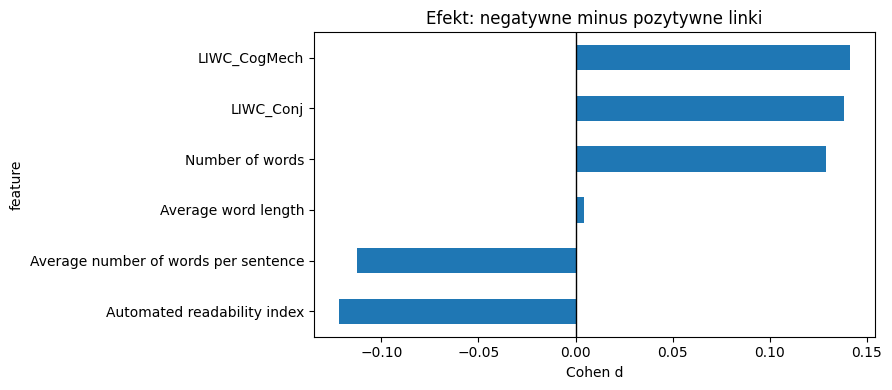

In [4]:
import matplotlib.pyplot as plt

plot_data = results.sort_values("cohens_d_negative_minus_positive")
ax = plot_data.plot.barh(
    x="feature",
    y="cohens_d_negative_minus_positive",
    figsize=(9, 4),
    legend=False,
    title="Efekt: negatywne minus pozytywne linki",
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Cohen d")
plt.tight_layout()


## Wniosek

Wyniki są mieszane. Negatywne linki mają niższy `Automated readability index` i niższą średnią liczbę słów na zdanie, co częściowo pasuje do hipotezy niższej złożoności.
Jednocześnie mają nieco więcej spójników (`LIWC_Conj`), więcej słów i wyższy `LIWC_CogMech`, więc hipotezy nie można przyjąć w całości.

Najrozsądniejszy wniosek: negatywne linki różnią się stylem i długością tekstu, ale nie jest to prosta zależność "negatywny = zawsze prostszy poznawczo".
